# Bootstrapped Feature Selection → Model Development & Evaluation (Nested CV)

This notebook implements a workflow where **feature selection is performed via bootstrapping** to identify a **stable feature set**, and then **model development + evaluation** is carried out using **nested cross-validation (CV)**.

## What this notebook does

* Runs **bootstrapped feature selection** to estimate **feature stability** (e.g., selection frequency) and produce a **final stable feature set**.
* Uses the **final stable feature set** to proceed into:

  * **model development / hyperparameter tuning** (inner CV),
  * **final training** on each outer-train split,
  * **evaluation** on each outer-test split.
* Reports **nested-CV performance** using a **fixed, stability-selected feature set** (rather than fold-specific feature sets).

## Key idea

Feature selection is done using **bootstrapping to measure stability**, producing a single **stable feature set**. That stable feature set is then treated as the input feature space for the **nested CV model development and evaluation** workflow, keeping the modeling evaluation unbiased while avoiding re-selecting features separately in each outer fold.


In [1]:
import ai_framework.ml_data_preprocessing as mdp
import ai_framework.ml_feature_selection as mfs
import ai_framework.ml_tuning_calib_interpret as mtci
import ai_framework.post_analysis as post
import ai_framework.utils as ut

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer



### Prepare data

In [2]:
path = 'tutorial/run_1/breast_cancer'
prefix = 'all_features'


data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data['feature_names']

ut.save_prepared_dataset_bundle(
    output_dir=path,
    X_raw=X,
    y=y,
    feature_names=feature_names,
    prefix=prefix,
)


# Load bundle dataset
# -----------------------------------------------------------------------------------------------------------------------------------
path = 'tutorial/run_1/breast_cancer'
prefix = 'all_features'
bundle = ut.load_prepared_dataset_bundle(output_dir=path, prefix=prefix, require=None,)


✅ Saved 3 artifact(s) to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer


In [3]:
df = pd.DataFrame(bundle['X_raw'],  
                  columns=bundle['feature_names'])
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.990000,10.380000,122.800003,1001.000000,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.379999,17.330000,184.600006,2019.000000,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.570000,17.770000,132.899994,1326.000000,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990000,23.410000,158.800003,1956.000000,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.690001,21.250000,130.000000,1203.000000,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570000,25.530001,152.500000,1709.000000,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.420000,20.379999,77.580002,386.100006,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910000,26.500000,98.870003,567.700012,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.290001,14.340000,135.100006,1297.000000,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540001,16.670000,152.199997,1575.000000,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.559999,22.389999,142.000000,1479.000000,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450001,26.400000,166.100006,2027.000000,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.129999,28.250000,131.199997,1261.000000,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690001,38.250000,155.000000,1731.000000,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.600000,28.080000,108.300003,858.099976,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980000,34.119999,126.699997,1124.000000,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.600000,29.330000,140.100006,1265.000000,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740000,39.419998,184.600006,1821.000000,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
df_v2, tab_meta = mdp.encode_categorical_and_ordinal( df=df ,
                                                 cat_cols=[], # explicitly mark categorical columns (none here)
                                                ord_cols=[], # explicitly mark ordinal columns (none here)
                                                low_card_max=3,
                                                ordinal_card_max=10,
                                                drop_first=True,
                                                return_metadata =True)
df_v2

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.990000,10.380000,122.800003,1001.000000,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.379999,17.330000,184.600006,2019.000000,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.570000,17.770000,132.899994,1326.000000,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990000,23.410000,158.800003,1956.000000,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.690001,21.250000,130.000000,1203.000000,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570000,25.530001,152.500000,1709.000000,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.420000,20.379999,77.580002,386.100006,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910000,26.500000,98.870003,567.700012,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.290001,14.340000,135.100006,1297.000000,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540001,16.670000,152.199997,1575.000000,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.559999,22.389999,142.000000,1479.000000,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450001,26.400000,166.100006,2027.000000,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.129999,28.250000,131.199997,1261.000000,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690001,38.250000,155.000000,1731.000000,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.600000,28.080000,108.300003,858.099976,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980000,34.119999,126.699997,1124.000000,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.600000,29.330000,140.100006,1265.000000,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740000,39.419998,184.600006,1821.000000,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
bundle['X_raw'] = df_v2.to_numpy()
bundle['feature_names'] = list(df_v2.columns)

### Explore data missingness and run data preprocessing

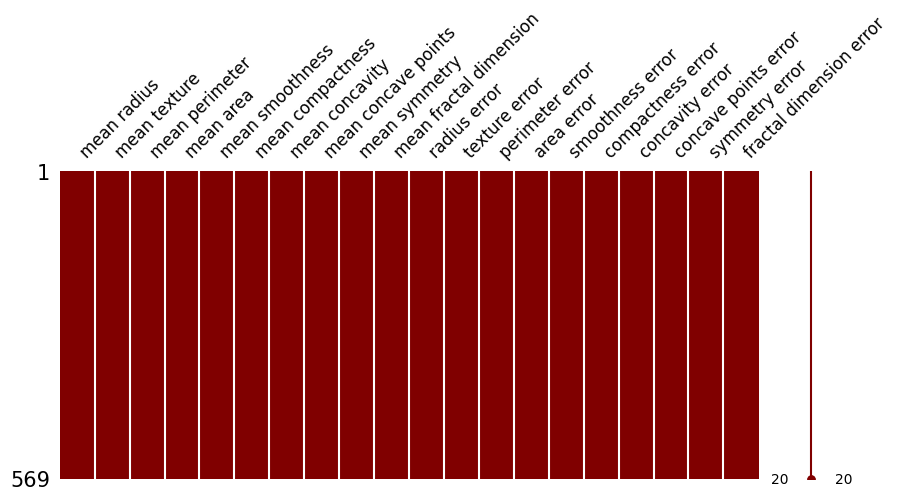

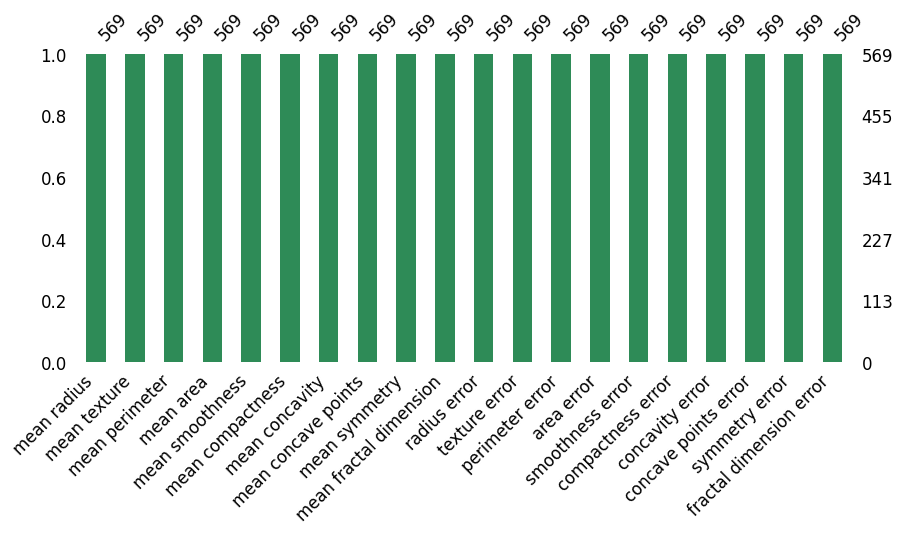

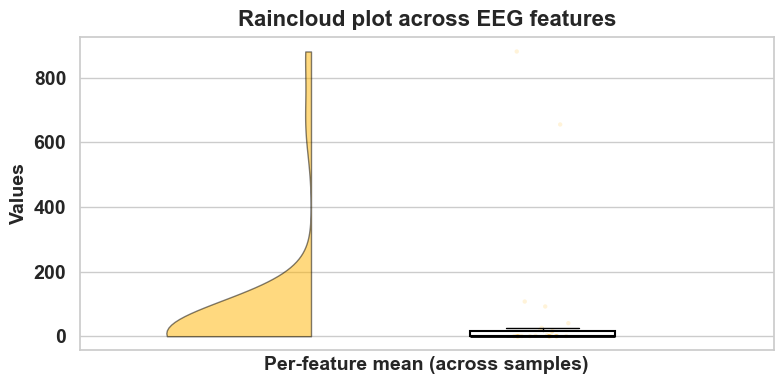

In [6]:

# Quick overview per epoch/feature, first 20 features
mdp.visualize_missingness(
    X_raw=bundle['X_raw'],
    feature_names=bundle['feature_names'],
    kind="matrix",
    max_features=20,
    figsize=(10, 4),
    fontsize=12,
    color="maroon",
    sort="ascending",
)

# Non-missing counts per feature, different style
mdp.visualize_missingness(
    X_raw=bundle['X_raw'],
    feature_names=bundle['feature_names'],
    kind="bar",
    max_features=20,
    figsize=(10, 4),
    fontsize=12,
    color="seagreen",
    sort="ascending",
)

summary_raw = mdp.summarize_feature_matrix(bundle['X_raw'], bundle['feature_names'])
mdp.plot_feature_stat_raincloud(summary_raw, stat="mean",  figsize=(8, 4), font_size=14, violin_half="right" )



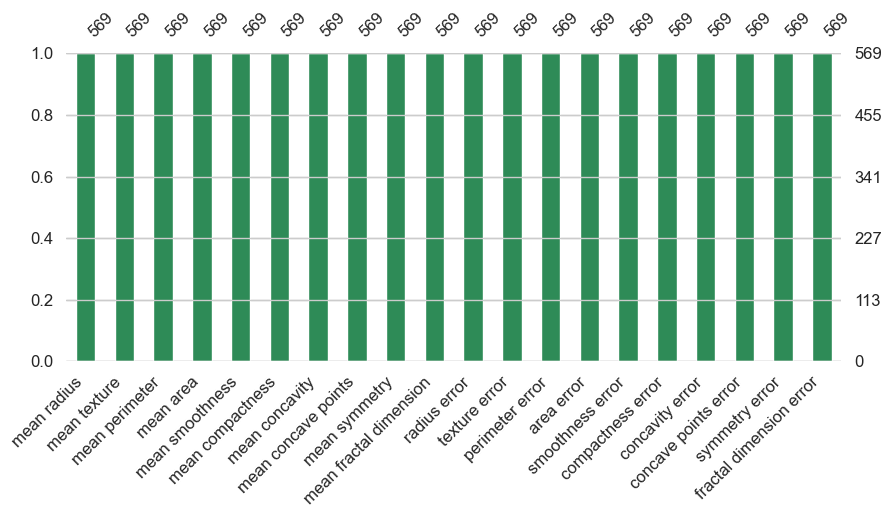

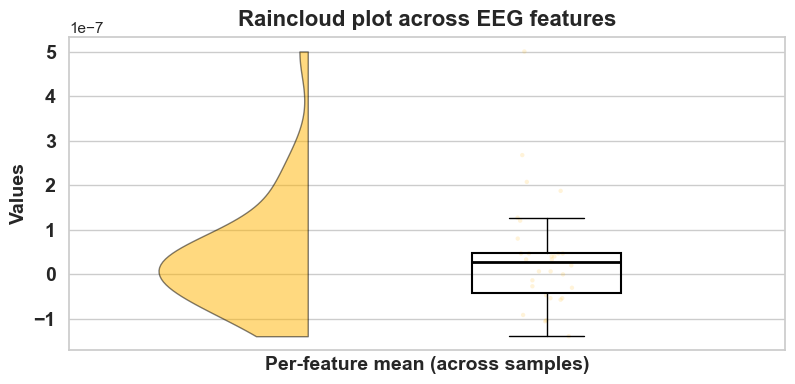

In [7]:


# Run data preprocessing
bundle = mdp.data_preprocessing_pipeline(
    bundle=bundle,
    lower_q = 0.05,
    upper_q = 0.95,
    impute_strategy = "median",
    preproc_key = "preproc",
    meta=None, # use tab_meta if you have additional metadata such as Age and Gender
)

# After scaling: re-check
# Quick overview per epoch/feature, first 20 features
# Non-missing counts per feature, different style
mdp.visualize_missingness(
    X_raw=bundle['X_scaled'],
    feature_names=bundle['feature_names'],
    kind="bar",
    max_features=20,
    figsize=(10, 4),
    fontsize=12,
    color="seagreen",
    sort="ascending",
)

summary_scaled = mdp.summarize_feature_matrix(bundle['X_scaled'], bundle['feature_names'])
mdp.plot_feature_stat_raincloud(summary_scaled, stat="mean",  figsize=(8, 4), font_size=14, violin_half="right" )




### Save/Load Preprocessed EEG Features (Winsorization, Imputation, Standard Scaling, and Fitted Preprocessors)

In [8]:
# All features
# -----------------------------------------------------------------------------------------------------------------------------------
path = 'tutorial/run_1/breast_cancer'
prefix = 'all_features_preproc'
mtci.save_all_results( output_dir=path, all_results = bundle,prefix=prefix,compress=True,)
bundle = mtci.load_all_results(output_dir=path,prefix=prefix,compress=True)
# -----------------------------------------------------------------------------------------------------------------------------------



✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\all_features_preproc.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\all_features_preproc.pkl.gz


# Feature Selection Pipeline

This notebook uses a **two-stage permutation-based feature ranking and selection pipeline**.

The pipeline is designed around two complementary stages:

1. **Exploration stage**
   - A relatively large set of top-ranked features is retained after the first stage.

2. **Refinement stage**
   - The second stage reranks the surviving features using the same core ranking procedure, but with more repeated feature exposure.


## Why `target_feature_appearances` matters

One of the most important stability parameters in this pipeline is `target_feature_appearances`.

- increasing `target_feature_appearances` increases the number of runs and gives each feature more repeated exposure
- increasing `subset_size` reduces the number of runs because more features are evaluated in each sampled subset
- increasing the number of incoming features increases the number of runs needed to maintain the same average exposure per feature

This makes `target_feature_appearances` one of the key parameters controlling the tradeoff between ranking stability and computational cost.

In practice, this parameter often has a strong influence on how stable the top 10 or top 20 features become.

The number of subset-sampling runs is computed as:

$$
n_{\mathrm{runs}} = \left\lceil \frac{\mathrm{target\_feature\_appearances} \times n_{\mathrm{features}}}{\mathrm{subset\_size}} \right\rceil

$$


## Why subset size matters

The `subset_sizes` parameter controls how many features are evaluated together in each sampled model.

Smaller subsets can sometimes make feature contributions easier to separate, but they require more subset-sampling runs to give every feature enough exposure. Larger subsets are usually more computationally efficient because more features are evaluated in each run.

A useful practical tradeoff is:

- **smaller subsets**: potentially sharper competition, but more expensive
- **larger subsets**: more efficient, often still effective when rankings are aggregated properly


In [9]:
%%time

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

RANK_SELECT_PIPELINE_CFG = {
    "defaults": {
        "task_type": "classification",       # "classification" or "regression"
        "scoring": "roc_auc",                # metric used by permutation_importance to score validation performance
        "n_splits": 5,                       # number of CV folds used in the selected splitter

        # fallback values used only if a stage does not override them
        "n_repeats": 25,                     # number of permutation shuffles per feature inside permutation_importance
        "target_feature_appearances": 5,    # target number of times each feature should appear across sampled subsets
        
        "random_state": 42,                  # base random seed for reproducibility
        "ranking_metric": "auto",            # final ranking rule: auto, mean_normalized_rank, or mean_importance
        "group_mode": False,                 # if True, repeatedly sample one row per group before ranking
        "group_iterations": 5,              # number of one-row-per-group resampling iterations when group_mode=True

        # row subsampling: for each feature-subset run, sample rows before CV
        # unused rows are discarded; CV + permutation importance use only sampled rows
        "row_subsampling": {
            "enabled": True,                 # if True, sample rows before CV for each feature-subset run
            "train_fraction": 0.8,           # fraction of rows kept for ranking in each run
            "stratify": True,                # preserve class balance when sampling rows for classification. Ignored for regression; use False for clarity
        },
    },
    "models": {
        "logistic_regression": LogisticRegression(max_iter=50000),          # model to rank features with
        "xgboost": XGBClassifier(objective= 'binary:logistic', eval_metric="logloss", n_estimators=100, max_depth=4, random_state=42),  # second model to rank features with
    },
    "stages": [
        {
            "name": "coarse_rank_select",    # stage label used in output/history
            "top_k": 25,                     # number of highest-ranked features to keep after this stage
            "subset_sizes": [15],         # feature subset sizes tested during ranking in this stage
             # stage-specific override
            "n_repeats": 25,
            "target_feature_appearances": 50,
        },
        {
            "name": "final_rank_select",     # second-stage label used in output/history
            "top_k": 15,                      # number of highest-ranked features to keep after this stage
            "subset_sizes": [15],         # feature subset sizes tested during ranking in this stage
             # stage-specific override
            "n_repeats": 25,
            "target_feature_appearances": 50,
        },

    ],
}
# n_runs = ceil((target_feature_appearances * n_features) / subset_size)



final_features = mfs.balanced_permutation_rank_select_pipeline(
    X=bundle['X_scaled'],
    y=bundle['y'],
    groups=None,
    feature_names=bundle['feature_names'],
    cfg=RANK_SELECT_PIPELINE_CFG, 
)





Feature selection stage=coarse_rank_select | model=logistic_regression:   0%|          | 0/1 [00:00<?, ?subset…

logistic_regression | subset=15:   0%|          | 0/100 [00:00<?, ?run/s]

Feature selection stage=final_rank_select | model=logistic_regression:   0%|          | 0/1 [00:00<?, ?subset/…

logistic_regression | subset=15:   0%|          | 0/84 [00:00<?, ?run/s]

Feature selection stage=coarse_rank_select | model=xgboost:   0%|          | 0/1 [00:00<?, ?subset/s]

xgboost | subset=15:   0%|          | 0/100 [00:00<?, ?run/s]

Feature selection stage=final_rank_select | model=xgboost:   0%|          | 0/1 [00:00<?, ?subset/s]

xgboost | subset=15:   0%|          | 0/84 [00:00<?, ?run/s]

CPU times: total: 22min 8s
Wall time: 2min 40s


### Save and load final features

In [10]:
# Load data and select the number of features you want
path = 'tutorial/run_1/breast_cancer'

# Save output
mtci.save_all_results(output_dir=path, all_results=final_features, prefix='final_features', compress=True)

# Load output
all_results = mtci.load_all_results(output_dir=path, prefix='final_features', compress=True) # Initialize dict to track ML results
final_features = mtci.load_all_results(output_dir=path, prefix='final_features', compress=True) # Stores final features for each model



✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz


## Config file

In [14]:
# ---------------------------------------------------------------------
# 1. Config: models, CV knobs, Optuna knobs, metric
# ---------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


# Select top k features
top_k = 7
lr_top = final_features['final_by_model']['logistic_regression']['feature_names_selected'][:top_k]
xgb_top  = final_features['final_by_model']['xgboost']['feature_names_selected'][:top_k]

config = {
    "cv": {
        "num_trials": 5,
        "n_outer_splits": 5,
        "n_inner_splits": 4,
    },
    "optuna": {
        "n_inner_trials": 300,
        "direction": "maximize",
         "n_jobs": 1,
    },
    "metric": {
        "scoring": "roc_auc",   #  "average_precision" | "roc_auc"
        "name": "AUROC",           # "AUPRC"  | "AUROC"
    },
    "models": {
        "logistic_regression": {
            "enabled": True, # flip to False if you don't want it to run
            "feature_names": lr_top, 
            "feature_strict": True,
            "n_features": None,

            "estimator_cls": LogisticRegression,
            "params": lambda trial: {
                "solver": "saga",
                "random_state": 42,
                "l1_ratio": (
                    trial.suggest_float("l1_ratio", 0.0, 1.0)
                    if trial is not None else 0.0
                ),
                "C": (
                    trial.suggest_float("C", 1e-1, 50.0, log=True)
                    if trial is not None else None
                ),
                "max_iter": (
                    trial.suggest_int("max_iter", 150000, 350000)
                    if trial is not None else None
                ),
                # "class_weight": (
                #     trial.suggest_categorical("class_weight", [None, "balanced"])
                #     if trial is not None else None
                # ),
            },
        },

        # Random Forest model
        "random_forest": {
            "enabled": False,   # flip to False if you don't want it to run
            "estimator_cls": RandomForestClassifier,
            "params": lambda trial: {
                "n_jobs": -1,
                "random_state": 42,

                "n_estimators": (
                    trial.suggest_int("n_estimators", 50, 500)
                    if trial is not None else None
                ),
                "ccp_alpha": (
                    trial.suggest_float("ccp_alpha", 0.0, 0.1)
                    if trial is not None else None
                ),
                "class_weight": (
                    trial.suggest_categorical(
                        "class_weight",
                        [None, "balanced", "balanced_subsample"],
                    )
                    if trial is not None else None
                ),
            },
        },

        # XGBoost model
        "xgboost": {
            "enabled": True, # flip to False if you don't want it to run
            "estimator_cls": XGBClassifier,
            "feature_names": xgb_top,
            "feature_strict": True,
            "n_features": None,
            "params": lambda trial: {
                # ---- fixed / always-on params ----
                "objective": "binary:logistic",
                "eval_metric": "auc",   # "aucpr" or "auc"
                "random_state": 42,
                "n_jobs": -1,
                "verbosity": 0,
                "tree_method": "hist",    # CPU-fast; use "gpu_hist" if you have a CUDA GPU

                # ---- tunable params (else None like your other models) ----
                #"n_estimators": 500,
                "n_estimators": (
                    trial.suggest_int("n_estimators", 200, 600)
                    if trial is not None else None
                ),
                "learning_rate": (
                    trial.suggest_float("learning_rate", 1e-2, 0.3, log=True)
                    if trial is not None else None
                ),

                "max_depth": (
                    trial.suggest_int("max_depth", 2, 6)
                    if trial is not None else None
                ),
                
                "min_child_weight": (
                    trial.suggest_float("min_child_weight", 5.0, 50.0, log=True)
                    if trial is not None else None
                ),
                ## stochasticity
                "subsample": (
                    trial.suggest_float("subsample", 0.5, 1.0)
                    if trial is not None else None
                ),
                "colsample_bytree": (
                    trial.suggest_float("colsample_bytree", 0.5, 1.0)
                    if trial is not None else None
                ),

                ## regularization
                # "gamma": (
                #     trial.suggest_float("gamma", 1, 10.0, log=True)
                #     if trial is not None else None
                # ),
                "reg_alpha": (
                    trial.suggest_float("reg_alpha", 0.01, 10.0, log=True)
                    if trial is not None else None
                ),
                "reg_lambda": (
                    trial.suggest_float("reg_lambda", 1, 20.0, log=True)
                    if trial is not None else None
                ),

                # ## Weight
                # "scale_pos_weight": (
                #     trial.suggest_float("scale_pos_weight", 1.0, 5.0, log=True)
                #     if trial is not None else None
                # ),

            },
        },

    },
}


### Summarize splits and label counts

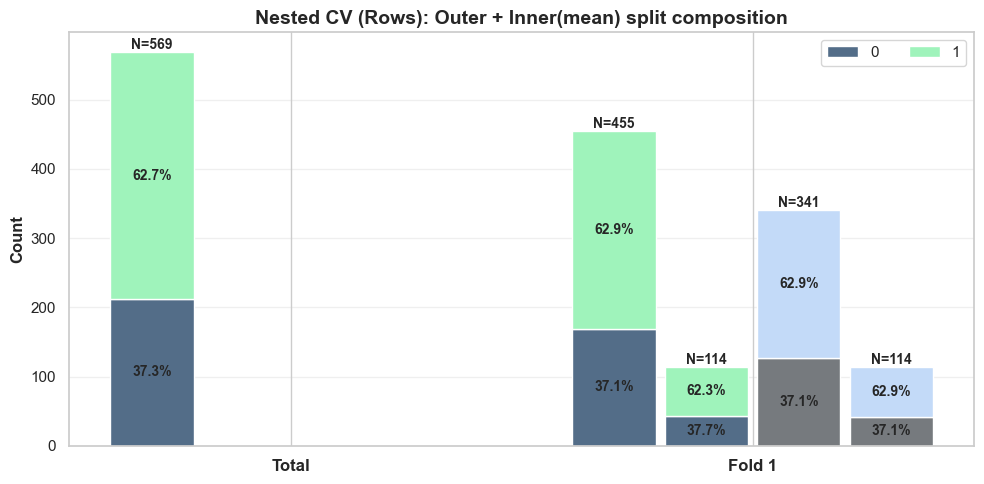

In [15]:
# ------------------------------------------------------------
# Summarize how nested CV splits your data WITHOUT training any models.
# ------------------------------------------------------------
X = final_features['final_by_model']['logistic_regression']['X']
y = final_features['y']
sizes = mtci.summarize_cv_split_sizes(
    X=X,            # feature matrix (rows = observations)
    y=y,                     # row-level labels (assumed constant within each patient)
    cfg=config,                        # must contain cfg["cv"]["n_outer_splits"], cfg["cv"]["n_inner_splits"]
    groups=None,           # patient IDs per row (same length as y)
    model_selection="StratifiedKFold",  # group-aware + stratified outer/inner splits
)


# ------------------------------------------------------------
# ROW-LEVEL plot (each row is an observation)
# Useful when you care about total number of ROWS used in each split.
# ------------------------------------------------------------
mtci.plot_outer_counts_and_class_percents(
    sizes,                         # output from summarize_cv_split_sizes(...)
    figsize=(10, 5),               # figure size
    font_size=12,                  # overall font size for labels/annotations
    show_segment_percents=True,    # write % inside each stacked segment
    show_total_labels=True,        # write N=... above each bar
    legend_loc="best",             # legend placement
    outer_fold_color=["#536D88", "#9FF3BB"],  # colors for Total + OUTER bars (per class)
    inner_fold_color=["#767A7E", "#C3DAF8"], # colors for INNER(mean) bars (per class)
    class_names=['0', '1'],     # optional: e.g., ["Negative", "Positive"]
    count_level="rows",            # plot ROW counts (not unique patients)
    title=None,                    # optional: override title (else default is used)
    folds_show=1,                  # show only first 2 outer folds (Total is always shown)
)


## Run model training with nested-cv

In [ ]:
%%time
# ---------------------------------------------------------------------
# Example: run nested CV for all enabled models in config
# ---------------------------------------------------------------------
all_results = {}

for model_name, m_cfg in config["models"].items():
    if not m_cfg.get("enabled", False):
        continue

    print(f"\n>>> Running nested CV for model: {model_name}")
      
    model_results = mtci.run_nested_cv_for_model(
        model_name=model_name,
        model_data=final_features["final_by_model"][model_name],
        y=final_features["y"],
        cfg=config,
        groups=None,   # or shared groups array if you have one
        model_selection="StratifiedKFold",
    )
    all_results[model_name] = model_results




## Functions to save and load ML model and outputs

In [17]:

path = 'tutorial/run_1/breast_cancer'
prefix = 'feat_nestedcv'

# Save output
mtci.save_all_results(output_dir=path, all_results=all_results, prefix=prefix, compress=True)

# Load output
all_results = mtci.load_all_results(output_dir=path, prefix=prefix, compress=True)

✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\feat_nestedcv.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\feat_nestedcv.pkl.gz


## Calibration

Calibrate the **uncalibrated probability scores** produced during nested CV for each `(model, trial, outer_fold)`.

For every outer fold, we generate **out-of-fold (OOF)** probabilities on the outer-train split and fit the selected calibrators (e.g., **Platt**, **Beta**), then apply them to the stored outer-test scores. Calibration is configured via `calibration_config` and respects **per-model feature selection**.


In [18]:
# Calibrate probability outputs AFTER nested CV, using per-model feature slicing (same as training).

all_results = mtci.calibrate_nested_cv_results(
    all_results=all_results,                # nested-CV output dict: {model_name: [fold_dict, ...]} (mutated in-place)
    final_features=final_features,          # full dataset  (must contain X/y arrays + feature names for slicing)
    cfg=config,                             # your config with per-model feature selection + model params
    groups=None,                            # optional group ids key (only needed for StratifiedGroupKFold; e.g. "combined_groups")
    model_selection="StratifiedKFold",      # CV splitter used to generate OOF train probs for calibration
    n_splits=5,                             # K folds for the OOF cross_val_predict on each outer-train split
    calibration_methods=["platt","beta"],   # which calibrators to fit on OOF train probs ("platt", "beta", or both)
    train_probs_source = "refit",           #"oof" (cross-validated) or "refit" (final_model train scores)
)


c:\Users\neyot\anaconda3\envs\ML_main\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


### Plot calibration-sensitive metrics (Brier score loss and Log loss) as grouped bar charts across calibration methods, with Train vs Test bars showing mean ± SD over outer folds.

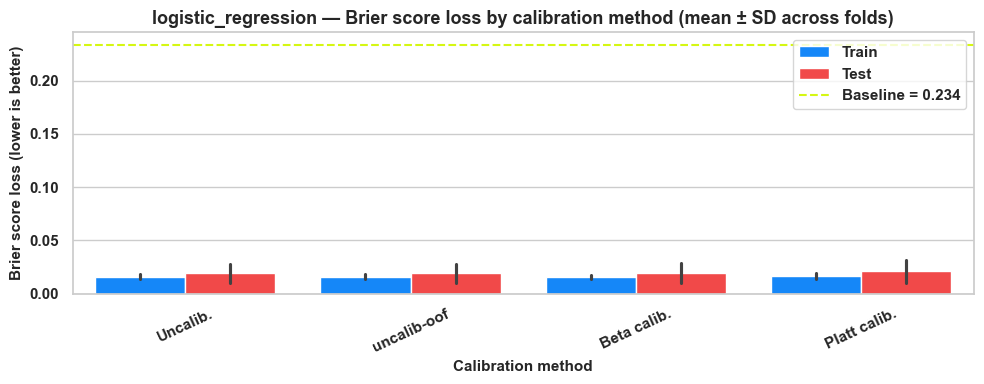

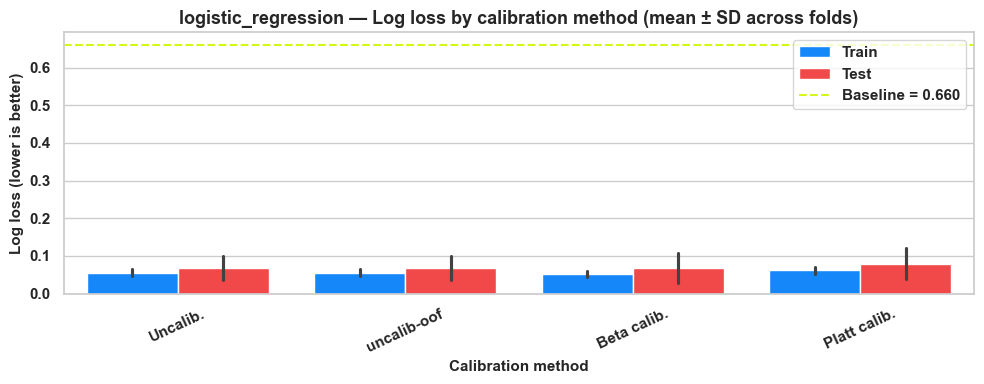

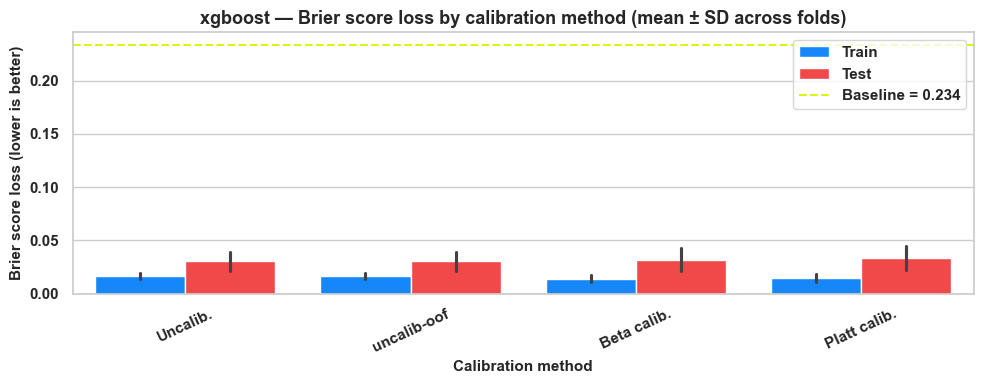

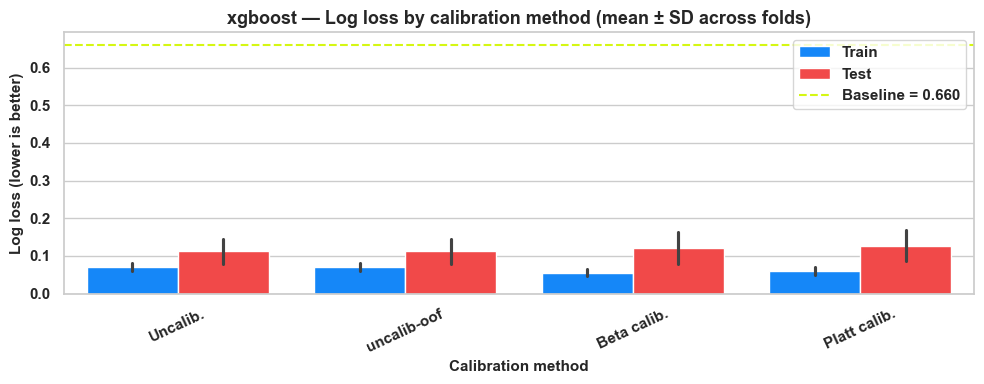

In [33]:

# Organize scores
eval_results = mtci.evaluate_nested_cv_results(
    all_results,
    metrics_to_compute=["average_precision", "roc_auc","brier_score_loss", "log_loss"],
    calibration_methods=["platt", "beta"],
)


alias = {
    "platt": "Platt calib.",
    "beta": "Beta calib.",
    "uncalib_oof": "uncalib-oof",
    "uncalibrated": "Uncalib.",
}

mtci.plot_brier_logloss_all_methods(
    eval_results,
    model_names=None,
    calibration_methods=["platt", "beta"],
    include_uncalibrated=True,
    include_uncalib_oof=True,
    sort_methods_by = "test",
    method_alias=alias,
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
     figsize=(10,4), legend_loc= "upper right", show_prevalence_baseline=True
)

### Compute pooled calibration **intercept (alpha) and slope (beta)** for each model and each calibration method using:

Models:   0%|          | 0/2 [00:00<?, ?it/s]

logistic_regression: methods:   0%|          | 0/3 [00:00<?, ?it/s]

xgboost: methods:   0%|          | 0/3 [00:00<?, ?it/s]


logistic_regression — Slope (β) (sorted by test closeness to ideal=1.0)
------------------------------------------------------------------------------------------
Method                       Train mean±std             Test mean±std              sort(|mean-ideal|)
Platt calib.                 1.0023 ± 0.0195            0.9203 ± 0.0358                    0.0797
uncalib                      1.2906 ± 0.0502            1.0988 ± 0.0900                    0.0988
Beta calib.                  1.0040 ± 0.0356            0.8085 ± 0.0630                    0.1915
------------------------------------------------------------------------------------------


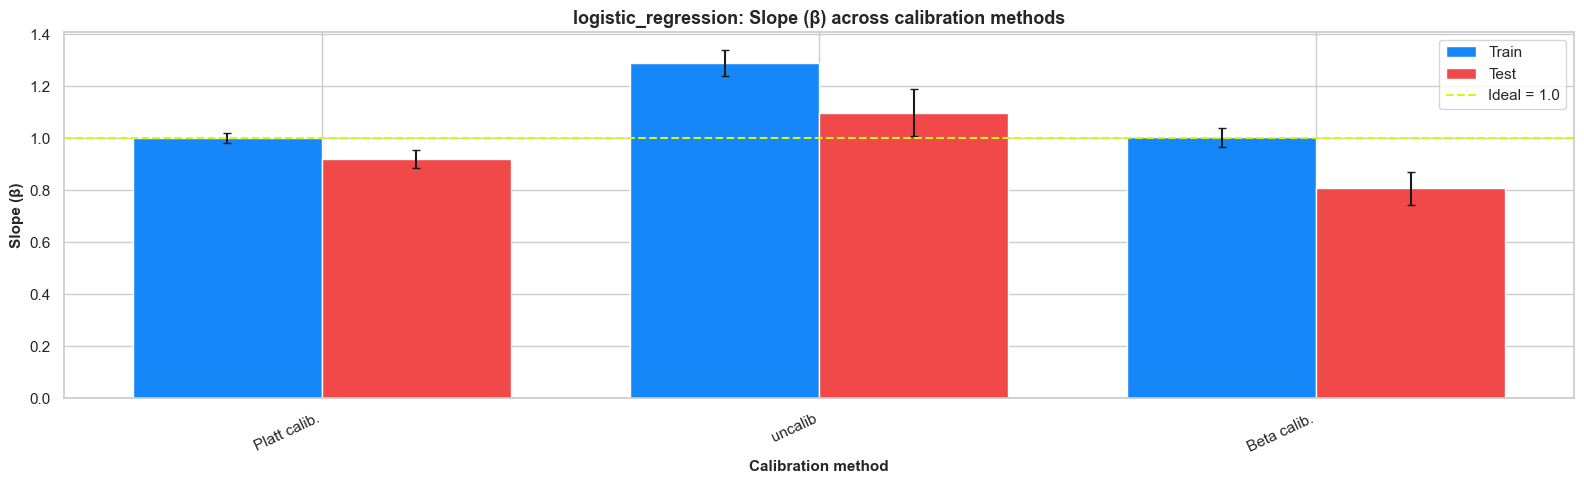


logistic_regression — Intercept (α) (sorted by test closeness to ideal=0.0)
------------------------------------------------------------------------------------------
Method                       Train mean±std             Test mean±std              sort(|mean-ideal|)
uncalib                      -0.1550 ± 0.0691           -0.0449 ± 0.1229                   0.0449
Platt calib.                 -0.0042 ± 0.0856           0.1040 ± 0.1498                    0.1040
Beta calib.                  -0.0030 ± 0.0780           0.2070 ± 0.1374                    0.2070
------------------------------------------------------------------------------------------


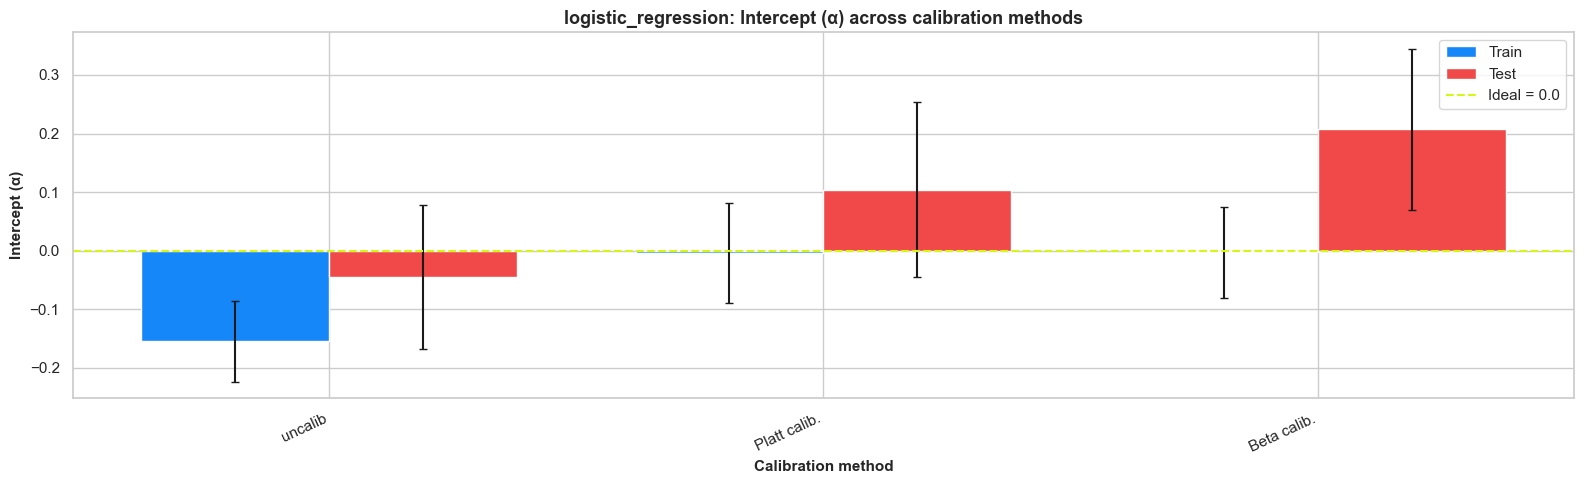


xgboost — Slope (β) (sorted by test closeness to ideal=1.0)
------------------------------------------------------------------------------------------
Method                       Train mean±std             Test mean±std              sort(|mean-ideal|)
uncalib                      1.4987 ± 0.0543            1.1129 ± 0.0550                    0.1129
Platt calib.                 1.0023 ± 0.0222            0.7800 ± 0.0271                    0.2200
Beta calib.                  1.0040 ± 0.0319            0.6778 ± 0.0389                    0.3222
------------------------------------------------------------------------------------------


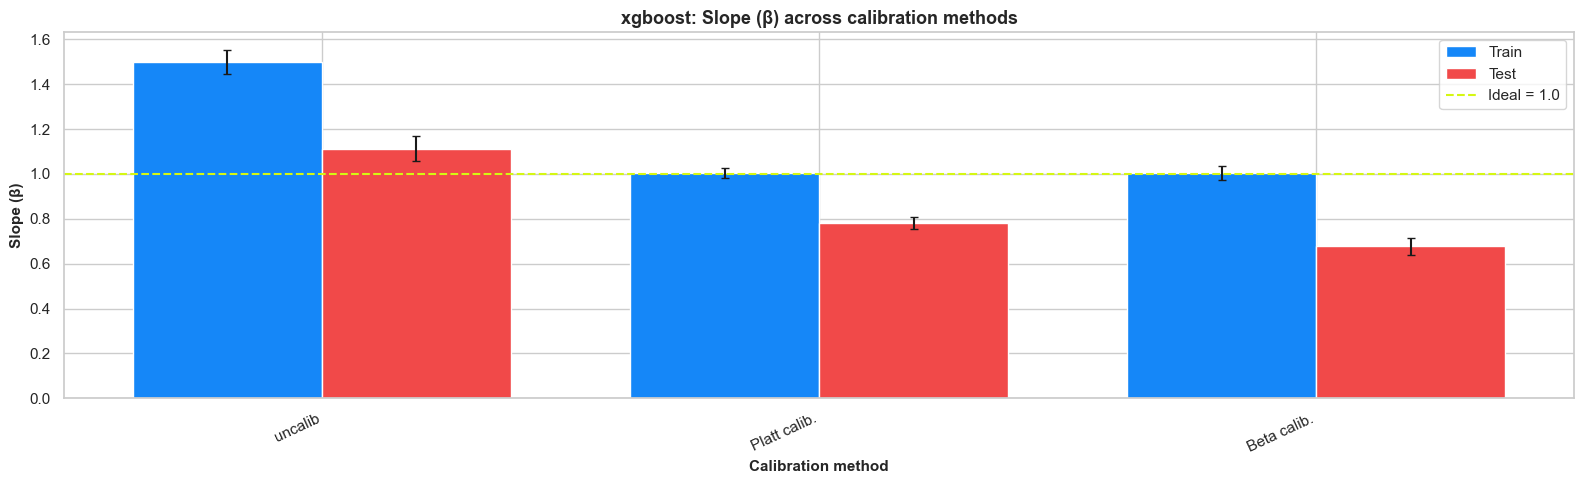


xgboost — Intercept (α) (sorted by test closeness to ideal=0.0)
------------------------------------------------------------------------------------------
Method                       Train mean±std             Test mean±std              sort(|mean-ideal|)
uncalib                      -0.2235 ± 0.0583           -0.0842 ± 0.1000                   0.0842
Platt calib.                 0.0008 ± 0.0779            0.2087 ± 0.1114                    0.2087
Beta calib.                  -0.0032 ± 0.0903           0.4513 ± 0.1388                    0.4513
------------------------------------------------------------------------------------------


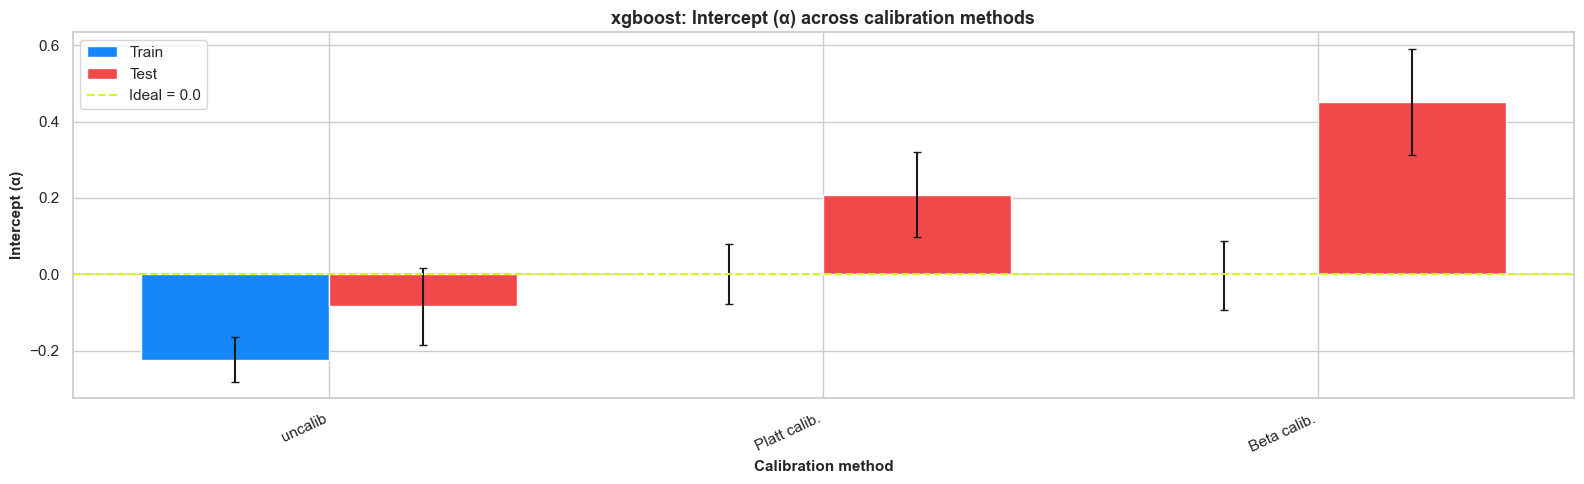

In [20]:
# -------------------------
# Example usage
# -------------------------
calibration_stats = mtci.pooled_bootstrap_calibration_stats_by_model(
    all_results,
    calibration_methods= ["platt", "beta"],  # or None to auto-discover
    n_boot=500, # bootstrap resamples used to estimate mean/std and 95% CI from pooled data
    seed=42,
    eps=1e-12,
)

# Short display names for plotting/table readability (method keys -> concise labels)
alias = {
    "platt": "Platt calib.",
    "beta": "Beta calib.",
    "uncalib_oof": "uncalib-oof",
    "uncalibrated": "Uncalib.",
}

mtci.plot_calibration_param(
    calibration_stats,
    model_name=None,
    methods=None,  # or ["platt", "beta"] + ["uncalibrated","uncalib_oof"]
    method_alias=alias,  # or ["platt", "beta"],+ ["uncalibrated","uncalib_oof"]
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
    sort_by="test",
    figsize=(16, 5),
    font_size=11,
    legend_loc="best",
    show_ideal_line=True,
    ideal_line_color="#D5F713",
    ideal_line_lw=1.5,
    ideal_line_ls="--",
    print_table=True,
    table_decimals=4,
)




## Log loss and brier score: 

Using the user selected calibration method that showed best performance 

 - brier score
 - log loss
 - intercept (alpha)
 - slope (beta)

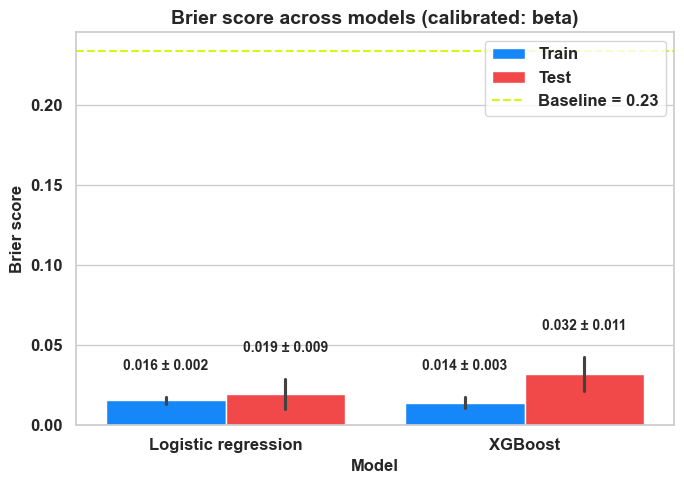

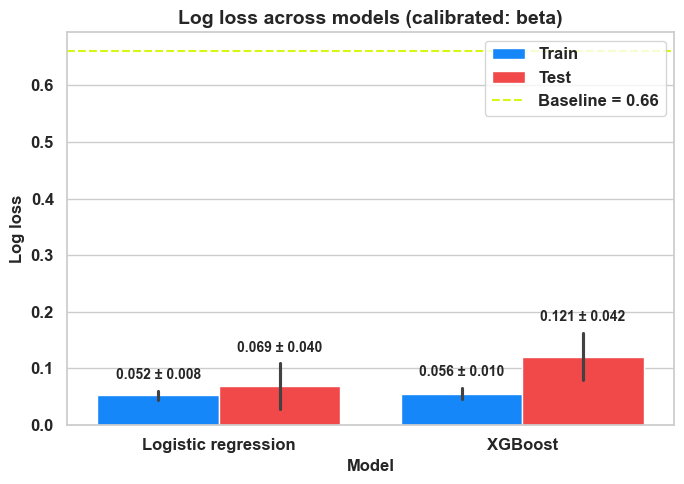

In [29]:

mtci.plot_brier_logloss(
    eval_results,
    model_names= None, # None= use all model with the same calibration
    calibration_method="beta",
    use_calibrated=True,
    include_uncalib_oof=False,
    method_alias={"logistic_regression": "Logistic regression", "xgboost": "XGBoost"},
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
    figsize=(7,5), legend_loc= "upper right", show_prevalence_baseline=True,
    annotate_font_size = 10,
    #logloss_ylim=(0, 1)  
)




## AUROC and AUPRC barplots

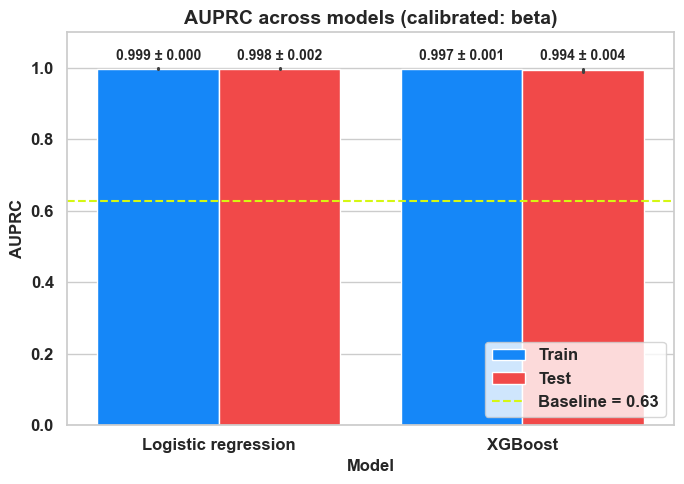

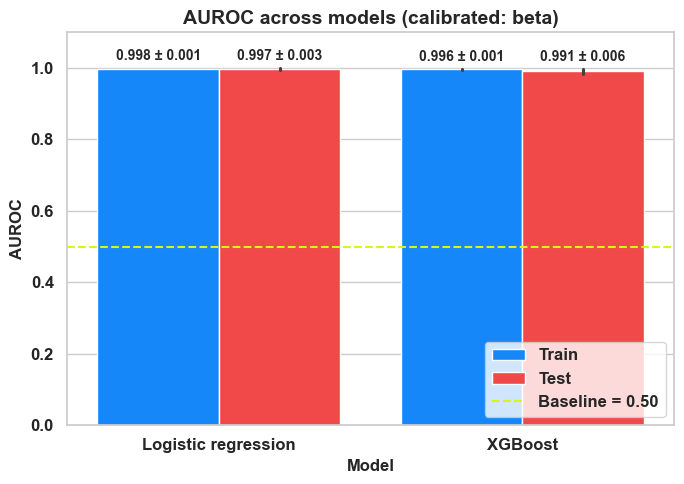

In [30]:
# # Uncalibrated plot if desired 
# mtci.plot_auprc_auroc(
#     eval_results,
#     model_names=None,
#     calibration_method=None,
#     use_calibrated=False,
#     include_uncalib_oof=True,
#     method_alias={"logistic_regression": "Logistic regression"},
#     split_palette={"Train": "#1587F8", "Test": "#F14949"},
#     figsize=(7,5), legend_loc= "upper right", show_prevalence_baseline=True,
#     annotate_font_size = 10
# )

mtci.plot_auprc_auroc(
    eval_results,
    model_names=None,
    calibration_method="beta",
    use_calibrated=True,
    include_uncalib_oof=False,
    method_alias={"logistic_regression": "Logistic regression", "xgboost": "XGBoost"},   # method_alias={"logistic_regression": "Logistic regression", "xgboost": "XGBoost"},
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
    figsize=(7,5), legend_loc= "lower right", show_prevalence_baseline=True,
    annotate_font_size = 10,
    auprc_ylim = (0, 1.1),
    auroc_ylim =(0, 1.1) 
)

## Balanced accuracy

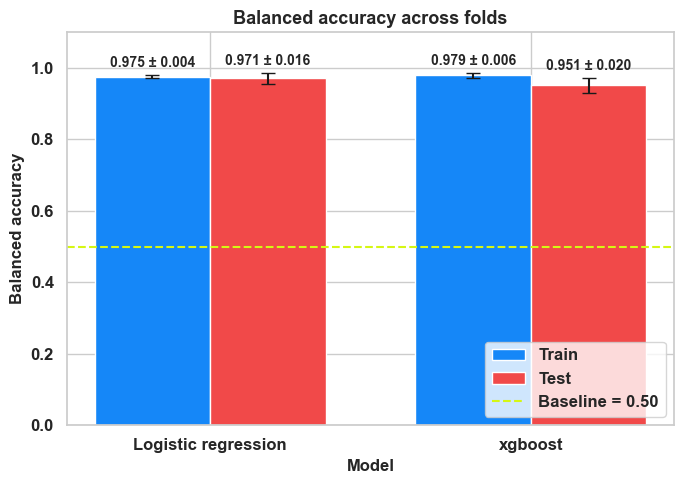

Per-model shared mean training-threshold summary:
  Logistic regression: shared threshold = 0.630 (from foldwise best-train thresholds: 0.630 ± 0.150)
  xgboost: shared threshold = 0.501 (from foldwise best-train thresholds: 0.501 ± 0.148)


In [23]:
mtci.barplot_balanced_accuracy(
    all_results,
    model_names=None,
    use_calibrated=True,
    calibration_method="beta",
    mode="mean_train_threshold",  # post-hoc best per split: ['mean_train_threshold','train_threshold', 'test_threshold', 'split_best']
    method_alias={"logistic_regression": "Logistic regression"},
    split_palette={"Train": "#1587F8", "Test": "#F14949"},
    show_baseline=True,
    baseline_color="#D5F713",
    figsize=(7,5),
    legend_loc="lower right",
    annotate_font_size = 10,
    ylim=(0,1.1),
    print_threshold_summary=True
)



## Calibration curve


>>> Generating calibration curve for model: logistic_regression


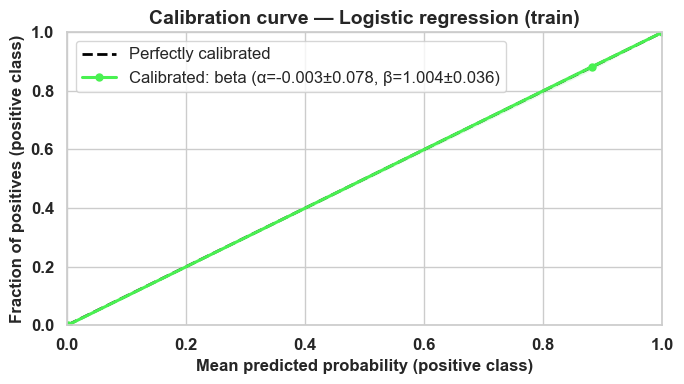

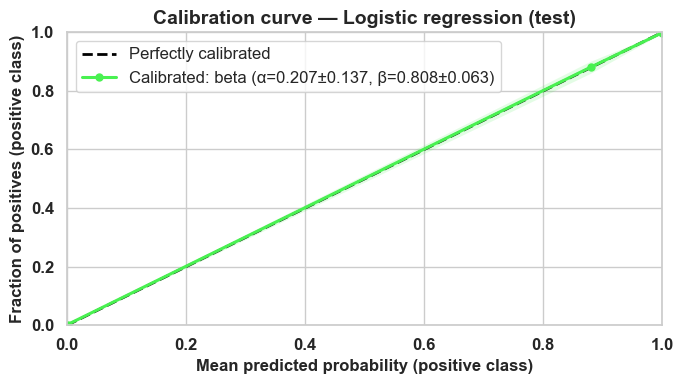

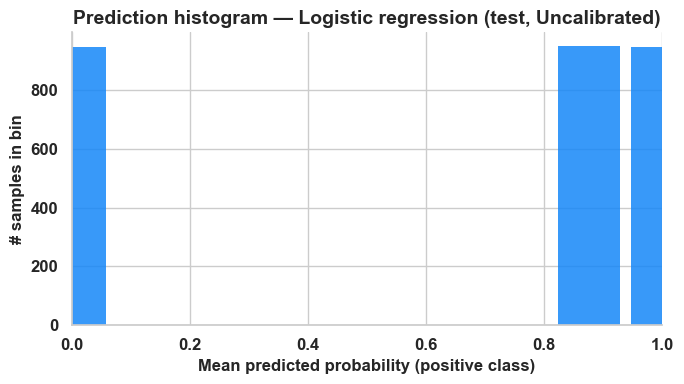

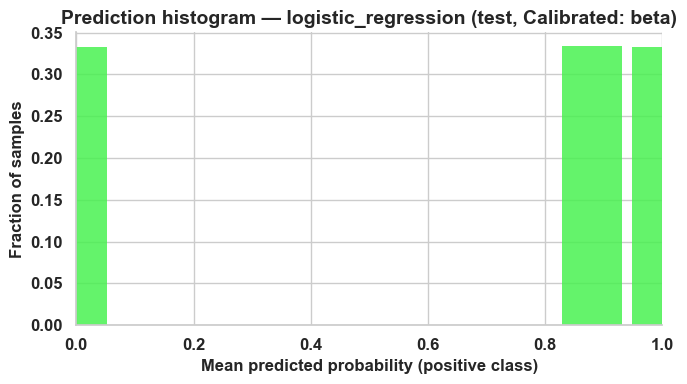


>>> DONE for model: logistic_regression

>>> Generating calibration curve for model: xgboost


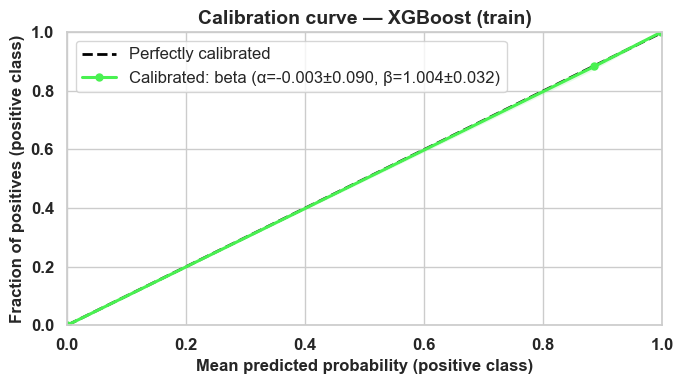

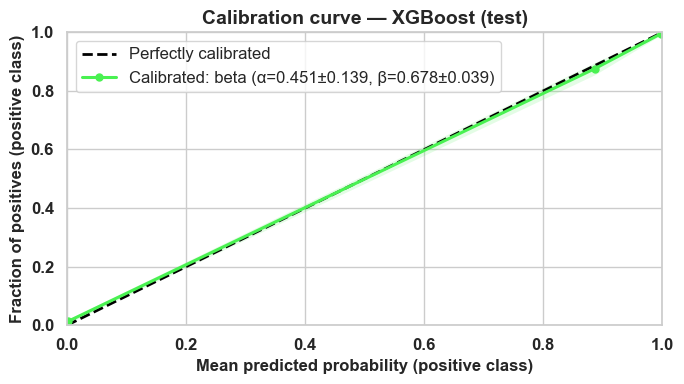

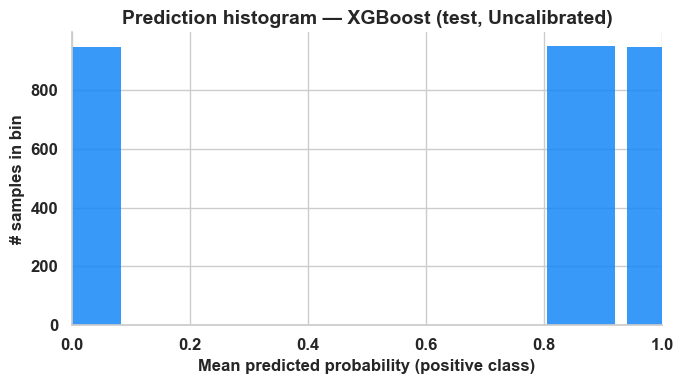

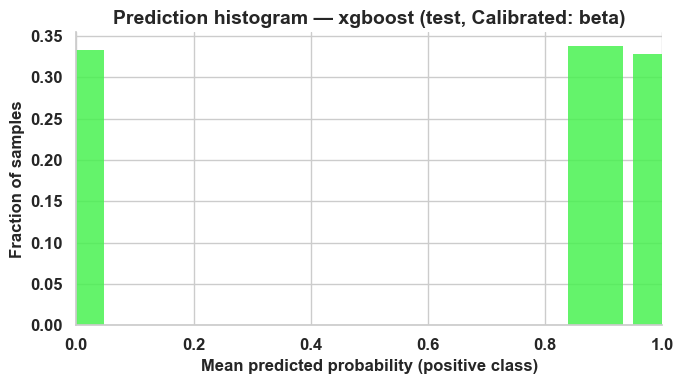


>>> DONE for model: xgboost


In [31]:
figsize=(7, 4)
calibration_methods=[ "beta"]
calibration_method_name = 'beta'

for model_name in ['logistic_regression', 'xgboost' ]: #'xgboost', 'logistic_regression'

    print(f"\n>>> Generating calibration curve for model: {model_name}")
    print('='*200)
    
    if model_name =="logistic_regression":
        method_alias={"logistic_regression": "Logistic regression"}

    elif model_name =="xgboost":
        method_alias={"xgboost": "XGBoost"}


    # model_name="logistic_regression"
    # figsize=(7, 4)

    calib_data = mtci.extract_calibration_data(
        all_results,
        model_name=model_name,
        calibration_methods=calibration_methods,
    )
    calib_data = mtci.calibration_data_prep(calib_data, n_bins=3, strategy="quantile")

    mtci.plot_calibration_curves(
        calib_data,
        model_name=model_name,
        methods=calibration_methods,
        include_uncalibrated=False,
        figsize=figsize,
        calibration_stats=calibration_stats,
        calibrated_color_map = {calibration_method_name: "#49F151"},
        show_alpha_beta=True,
        alpha_beta_decimals=3,
        method_alias=method_alias,
    )


    mtci.plot_calibration_histogram(
        calib_data,
        model_name=model_name,
        split="test",
        variant="uncalib",
        figsize=figsize,
        method_alias=method_alias,
        uncalib_color="#1587F8",
        calibrated_color_map={calibration_method_name: "#49F151"},
    )

    mtci.plot_calibration_histogram(
        calib_data,
        model_name=model_name,
        split="test",
        variant=calibration_method_name,
        normalize=True,
        figsize=figsize,
        calibrated_color_map={calibration_method_name: "#49F151"},
    )

   
    print(f"\n>>> DONE for model: {model_name}")

    

## Permutation feature importance (nested CV)

This section computes **permutation feature importance** for each model using the **outer test split** from nested cross-validation, then aggregates the results across folds for visualization.

### What permutation importance measures
Permutation importance estimates how much each feature contributes to model performance by:
1. Measuring the model’s baseline score on the test set (using the chosen `scoring` metric).
2. Shuffling one feature column at a time (breaking its relationship with the target).
3. Measuring how much the score drops after shuffling.
4. Repeating the shuffle multiple times (`n_repeats`) to get a stable distribution of importance values.

Larger importance values mean the model’s performance degrades more when that feature is permuted, suggesting the feature is more influential.

### Pipeline steps
We use a convenience pipeline that wraps two steps:

1. **Compute fold-level importances (outer test only)**  
   For each model and each outer fold, compute permutation importance using the already-fitted `final_model` and that fold’s `outer_test_idx`.

2. **Combine across folds**  
   Concatenate the importance repeats from all folds into one matrix per model:
   - `combined_importances[model_name]` has shape `(n_features, total_repeats)`  
   where `total_repeats = n_repeats × (# outer folds)`.

### Key parameters (what to tune)
- `scoring`: metric used to quantify the performance drop (e.g., `"roc_auc"` or `"average_precision"`).
- `n_repeats`: number of shuffles per feature per fold (higher = more stable, slower).
- `n_jobs`: parallelism (`-1` uses all CPU cores).
- `random_state`: controls shuffle reproducibility.

### Output used for plotting
The pipeline returns:
- `all_results` (mutated in-place with per-fold importance matrices)
- `combined_importances` (combined importance matrices used directly by the plotting function)

After this, we typically visualize the **top N features** by mean importance with error bars (std across repeats).


In [25]:
%%time

all_results, combined_importances, model_feature_names = mtci.run_permutation_importance_pipeline(
    all_results=all_results,                 # nested-CV results dict (mutated in-place to store fold-level permutation arrays)
    final_features=final_features,           # full dataset bundle (contains X/y arrays + feature_names for slicing)
    cfg=config,                              # config with per-model feature selection: feature_names OR n_features (mirrors training)
    scoring="roc_auc",                       # metric used to measure performance drop when a feature is permuted ("average_precision" also common)
    n_repeats=1000,                          # number of shuffles per feature per fold (higher = more stable, slower)
    random_state=42,                         # seed for reproducible shuffling
    n_jobs=-1,                               # parallelism for permutation_importance (-1 uses all cores)
)



Permutation importance pipeline:   0%|          | 0/2 [00:00<?, ?step/s]

logistic_regression: perm imp folds:   0%|          | 0/25 [00:00<?, ?it/s]

xgboost: perm imp folds:   0%|          | 0/25 [00:00<?, ?it/s]

CPU times: total: 35.2 s
Wall time: 50.3 s


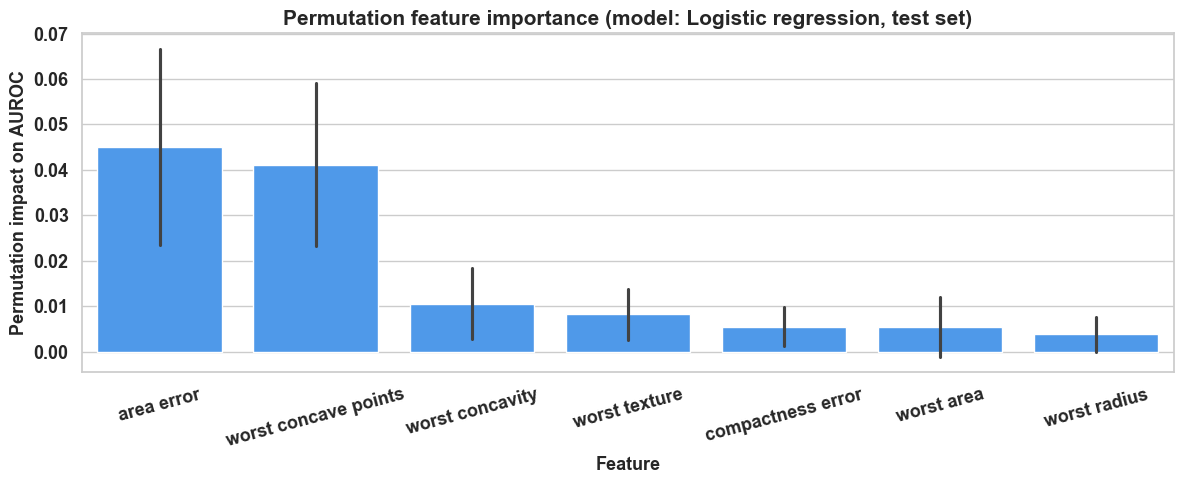

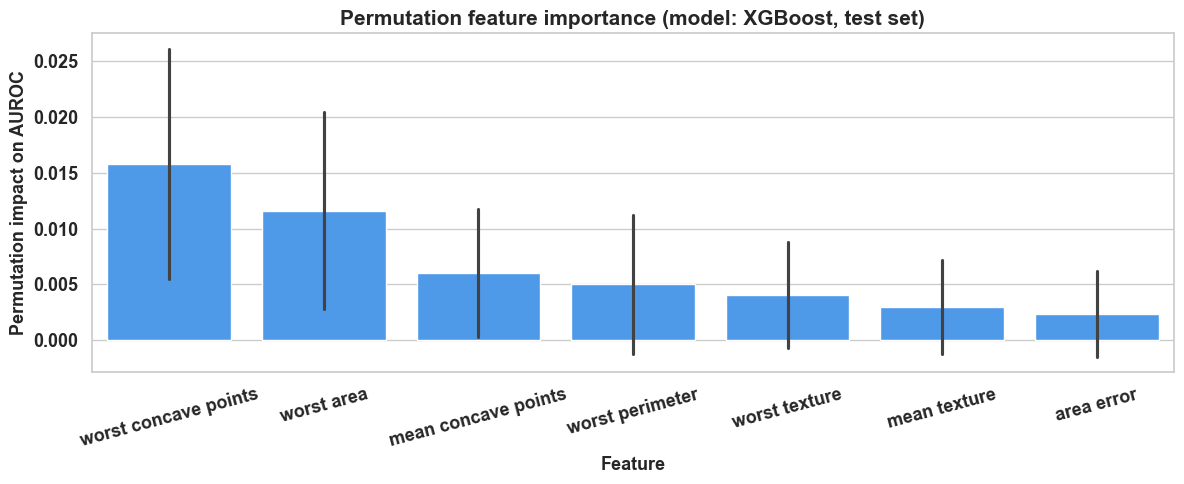

In [32]:

mtci.plot_permutation_importances_barplot(
    combined_importances=combined_importances,   # dict: model_name -> (n_features_model, total_repeats) matrix
    model_name=None,                             # None = plot ALL models; or set "xgboost", "logistic_regression", etc.
    feature_names=model_feature_names,           # dict: {model_name: [feature names used by that model]}
    top_n=12,                                    # show only the top 15 features by mean importance
    scoring="AUROC",                             # label only (computation used scoring="roc_auc" above)
    figsize=(12, 5),                              # figure size
    font_size=13,                                # base font size
    color="#4F99E9",                             # bar color
    x_tick_rotation=15,                          # rotate x labels for readability
    method_alias={                               # map internal model keys -> display names
        "logistic_regression": "Logistic regression",
    "xgboost": "XGBoost",
    },
)



## Partial dependence plots (PDPs) pipeline 

This section runs the full **Partial Dependence Plot (PDP)** workflow for the *EEG feature* dataset and then plots the **mean PDP ± 1 std** across outer folds.

### 1) Run the PDP pipeline
`run_pdp_pipeline(...)` combines three main steps into one call:

1. **Compute PDPs per outer fold** using the already-fitted `final_model` stored in `all_results`.
   - Handles low-cardinality/binary features by **padding PDP grids with NaNs** internally.
2. **Aggregate PDP points** across folds into a long-format DataFrame per model (`pdp_agg[model_name]`).
3. **Compute mean and std PDP curves** across folds on a common grid (`pdp_agg[f"{model_name}_mean_pdp"]`).

### 2) Plot mean PDP ± std
Finally, `plot_all_mean_pdp_with_std(...)` plots the **fold-averaged PDP curve** (mean) with a shaded band (± std) for every feature.

Key plotting controls:
- `model_name=None`: plot for all available models (or set a specific model, e.g. `"logistic_regression"`).



PDP pipeline:   0%|          | 0/3 [00:00<?, ?step/s]


=== Computing PDP for model: logistic_regression ===


logistic_regression folds:   0%|          | 0/25 [00:00<?, ?it/s]


=== Computing PDP for model: xgboost ===


xgboost folds:   0%|          | 0/25 [00:00<?, ?it/s]

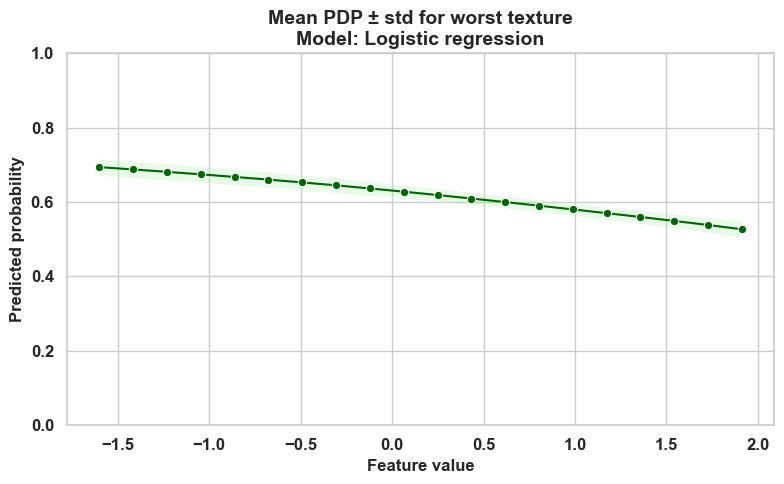

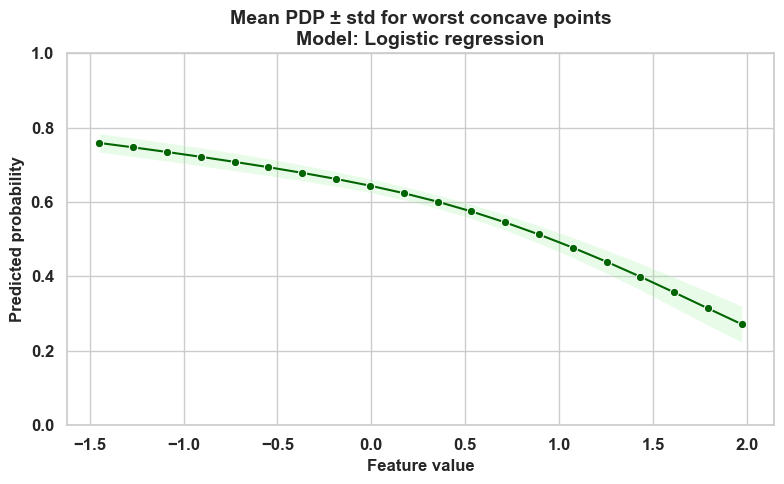

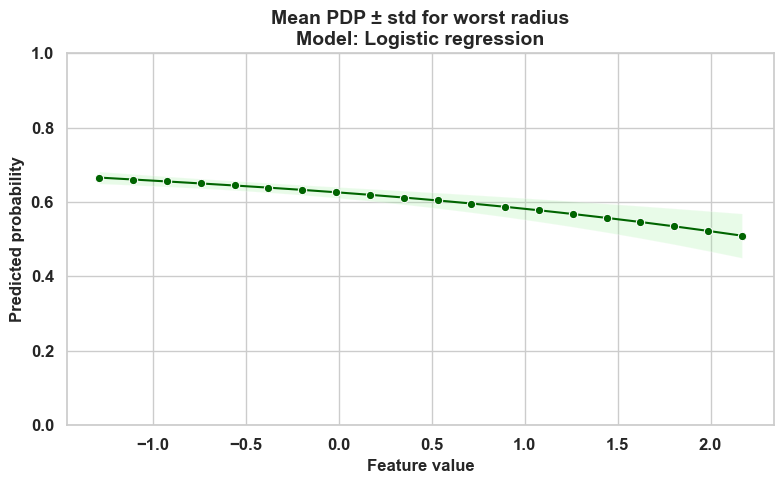

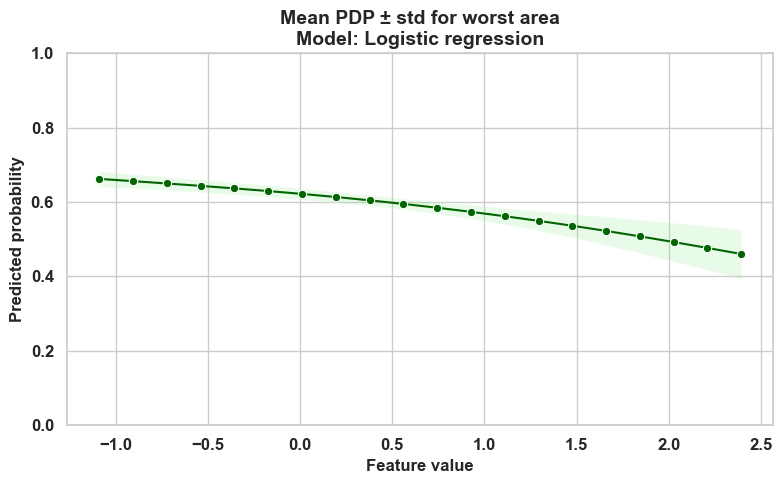

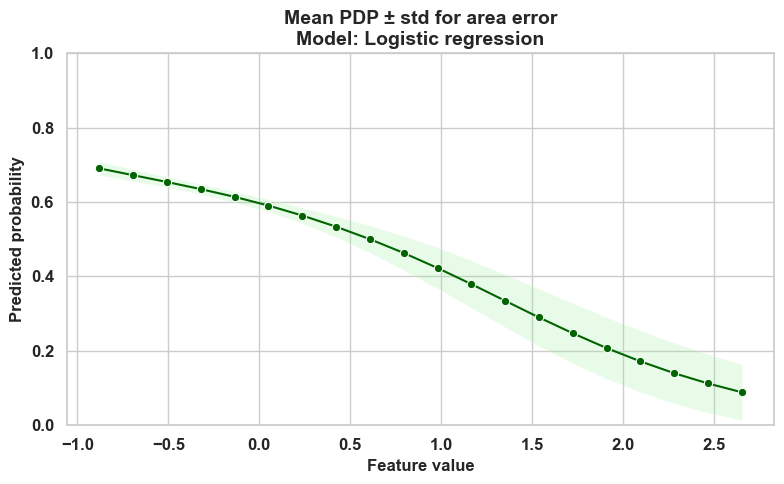

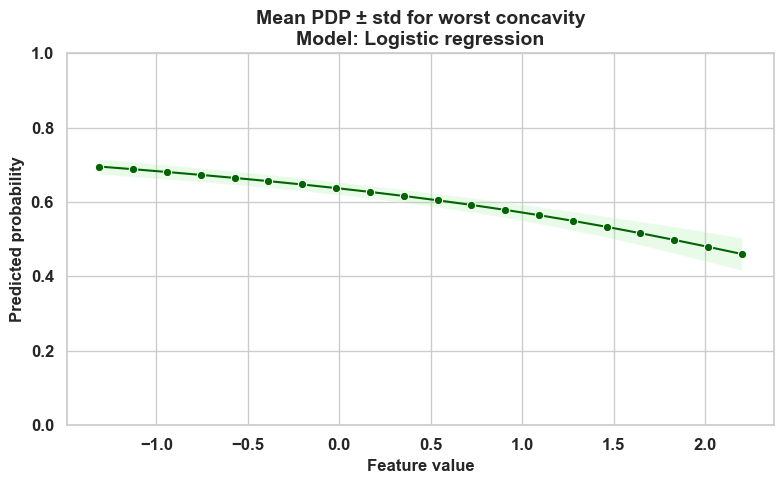

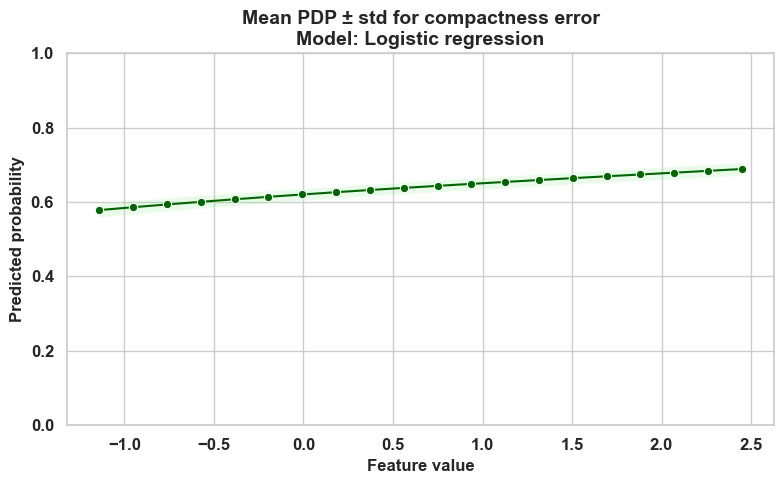

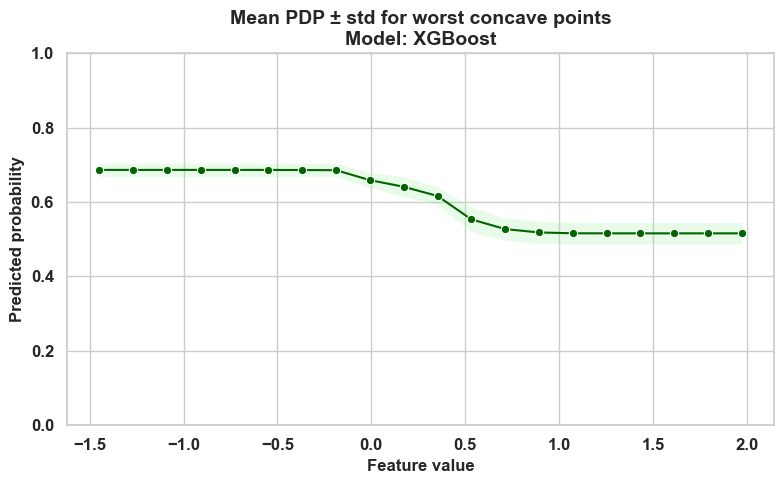

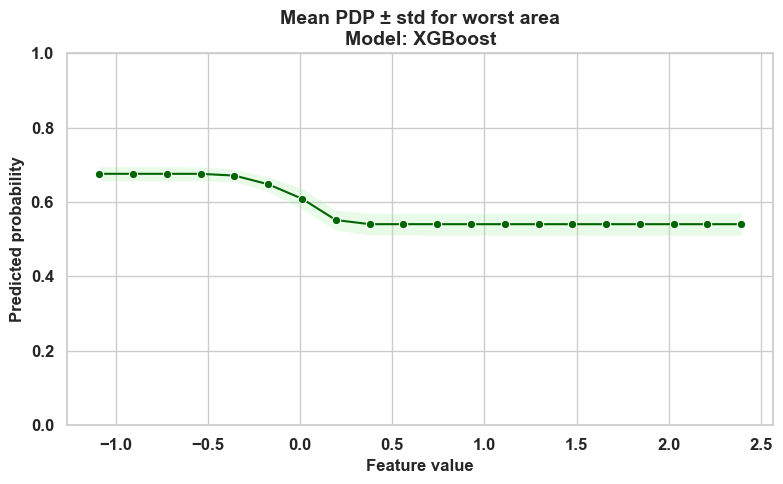

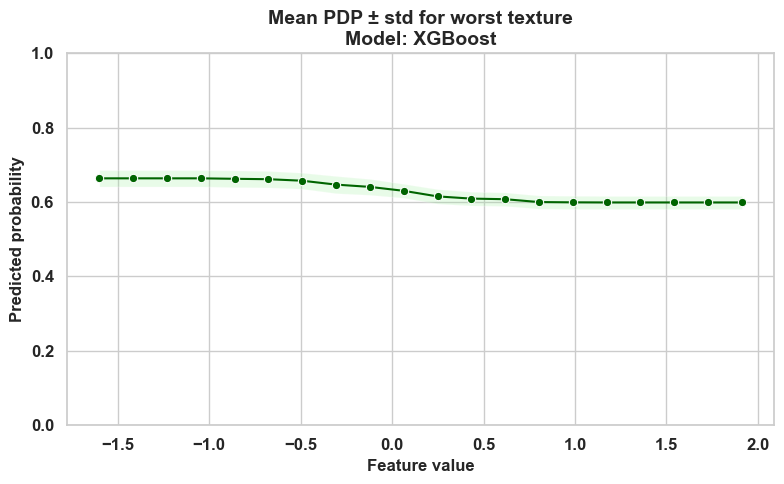

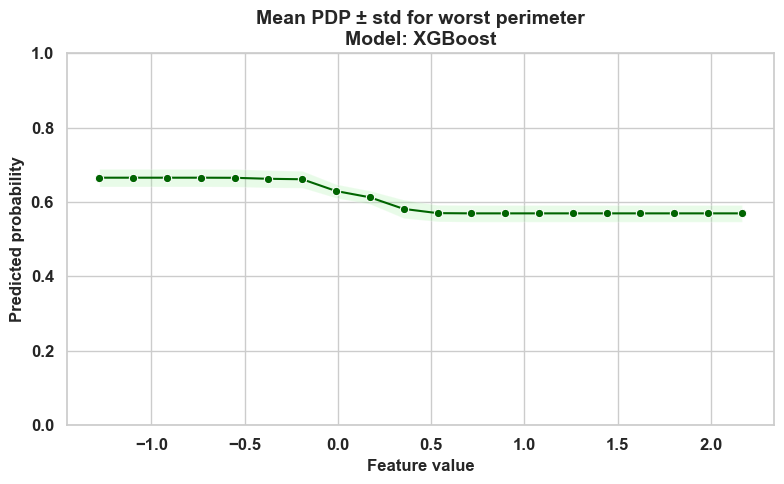

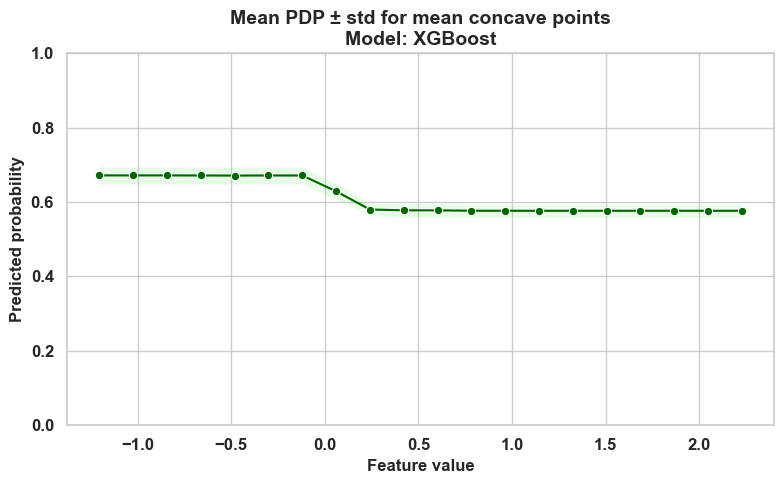

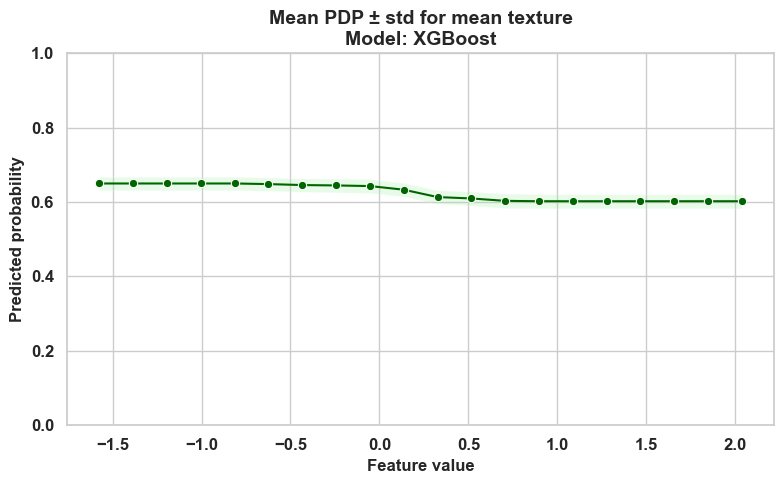

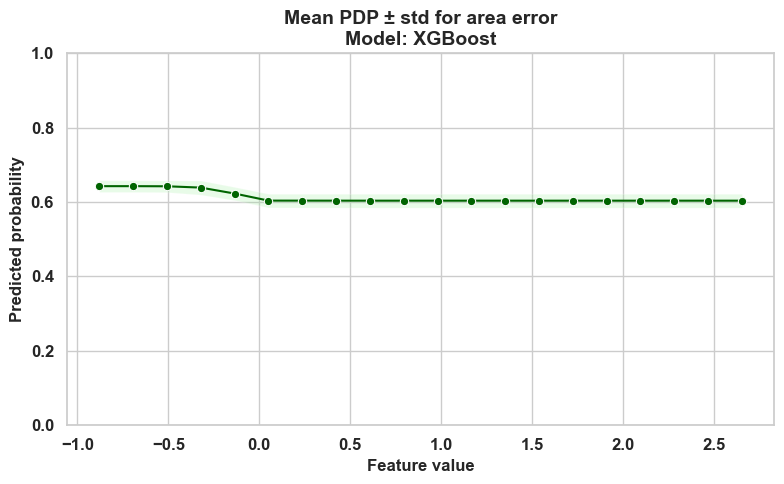

In [27]:
# ------------------------------------------------------------
# 1) Run PDP pipeline (compute per-fold PDPs -> aggregate -> mean/std -> optional raw x-axis)
# ------------------------------------------------------------
all_results, pdp_agg, model_feature_names = mtci.run_pdp_pipeline(
    all_results=all_results,                  # nested-CV outputs (dict of folds per model). Mutated in-place to store fold PDP arrays.
    final_features=final_features,            # full dataset (contains X/y arrays + feature_names for slicing)
    cfg=config,                               # config with per-model feature selection: feature_names OR n_features (mirrors training)

    # Which outer split to compute PDPs on
    data_source="test",          # "test" = PDP on outer-test sets only (most honest). "train" or "both" also allowed.

    # How sklearn builds the PDP x-grid per feature (before we later interpolate to a canonical grid)
    grid_resolution=100,         # requested # of grid points for continuous features (discrete features may produce fewer)
    percentiles=(0.0, 1.0),      # x-grid boundaries as percentiles of observed feature values (0..1 = full range)
    centered=False,              # if True, centers PDP curves (changes interpretation; shows deviations from baseline)

    # How we average curves across folds (canonical grid for mean/std)
    n_points=20,                 # number of points in canonical grid for continuous features (bigger => smoother mean curve)
    discrete_threshold=10,       # if a feature has <= this many unique values, treat as discrete (use unique values grid)
)



# ------------------------------------------------------------
# 2) Plot mean PDP ± std for every feature (one figure per feature per model)
# ------------------------------------------------------------
mtci.plot_all_mean_pdp_with_std(
    pdp_agg,                         # output dict from pipeline containing per-model mean/std tables

    # Which models to plot
    model_name=None,                 # None = plot ALL models in pdp_agg; or set "xgboost", "logistic_regression", etc.

    # Feature naming (important now that each model can have different feature sets)
    feature_names=model_feature_names,  # dict: {model_name: [feature names used by that model]} (like perm-importance barplot)

    # Plot formatting
    figsize=(8, 5),                  # size of each feature plot
    font_size=12,                    # base font size for labels/ticks/titles
    y_lim=(0.0, 1.0),                # optional fixed y-axis bounds (useful for probability outputs)
    line_color="darkgreen",          # PDP mean line color
    fill_color="lightgreen",         # color for the ±std shaded band
    sns_style="whitegrid",           # seaborn styling preset
    fill_alpha=0.2,                  # transparency for shaded band
    fill_edgecolor=None,             # edge outline for shaded band (None = no outline)

    # Optional: nicer names in titles
    method_alias={                   # map internal model keys -> display names used in plot titles
        "logistic_regression": "Logistic regression",
        "xgboost": "XGBoost",
    },
)


### Save final results

In [28]:


# Save output
mtci.save_all_results(output_dir='tutorial/run_1/breast_cancer', all_results=all_results, prefix='final_result', compress=True)
mtci.save_all_results(output_dir='tutorial/run_1/breast_cancer', all_results=bundle, prefix='final_bundle', compress=True)

# Load output
# all_results    = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)
# bundle         = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_bundle', compress=True)

✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_result.pkl.gz
✅ Saved all_results to: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_bundle.pkl.gz


WindowsPath('tutorial/run_1/breast_cancer')